In [1]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

try:
    import maglab
except ImportError:
    maglab = None


In [2]:
TWIST_DIR = Path(r"..\recon-scripts\twist")

reference_case = {
    "label": "16loss",
    "path": r"..\recon-scripts\dmi_loss\16_layers_loss\results\loss1.6e+01_wphi1.0e+07",
    "output_csv": "16loss_twist_angle.csv",
}

case_dirs = [
    {"label": "no_Em", "path": r"..\recon-scripts\separate\loss16_analyse\wm0\results\loss1.6e+01_wphi1.0e+00", "output_csv": "no_Em_twist_angle.csv"},
    {"label": "16loss", "path": r"..\recon-scripts\dmi_loss\16_layers_loss\results\loss1.6e+01_wphi1.0e+07", "output_csv": "16loss_twist_angle.csv"},
    {"label": "exc", "path": r"..\recon-scripts\separate\loss16_analyse\1_Eexc\results\loss1.6e+01_wphi1.0e+07", "output_csv": "exc_twist_angle.csv"},
    {"label": "exc+demag", "path": r"..\recon-scripts\separate\3_Eexc_Edemag\results\loss1.6e+01_wphi1.0e+07", "output_csv": "exc_demag_twist_angle.csv"},
    {"label": "exc+dmi", "path": r"..\recon-scripts\separate\2_Eexc_DMI\results\loss1.6e+01_wphi1.0e+07", "output_csv": "exc_dmi_twist_angle.csv"},
]

angles_range = (0, 360, 1)
target_mz = 0.0
reference_start_z = 55
reference_record_csv = Path(reference_case["path"]) / "16loss_twist_angle.csv"
angle_tolerance = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

check_rows = []
for case in [reference_case, *case_dirs]:
    case_path = Path(case["path"])
    check_rows.append({
        "label": case["label"],
        "path": str(case_path),
        "exists": case_path.exists(),
        "has_spin_npy": (case_path / "spin.npy").exists(),
        "has_final_pth": (case_path / "final.pth").exists(),
    })
path_check_df = pd.DataFrame(check_rows)
display(path_check_df)

missing_df = path_check_df[~path_check_df["exists"] | (~path_check_df["has_spin_npy"] & ~path_check_df["has_final_pth"])]
if not missing_df.empty:
    raise FileNotFoundError(f"Invalid input directories:\n{missing_df.to_string(index=False)}")
if not reference_record_csv.exists():
    raise FileNotFoundError(reference_record_csv)


Using device: cuda


,label,path,exists,has_spin_npy,has_final_pth
0,16loss,D:\Projects\HFCAS\TargetSkyrmion\targetdata\3d...,True,True,True
1,no_Em,D:\Projects\HFCAS\TargetSkyrmion\targetdata\4s...,True,True,True
2,16loss,D:\Projects\HFCAS\TargetSkyrmion\targetdata\3d...,True,True,True
3,exc,D:\Projects\HFCAS\TargetSkyrmion\targetdata\4s...,True,True,True
4,exc+demag,D:\Projects\HFCAS\TargetSkyrmion\targetdata\4s...,True,True,True
5,exc+dmi,D:\Projects\HFCAS\TargetSkyrmion\targetdata\4s...,True,True,True


In [3]:
def get_spin(file_path, device=None, prefer_npy=True):
    file_path = Path(file_path)
    spin_npy = file_path / "spin.npy"
    final_pth = file_path / "final.pth"

    if prefer_npy and spin_npy.exists():
        spin = torch.as_tensor(np.load(spin_npy), dtype=torch.float32)
    elif final_pth.exists():
        if maglab is None:
            raise ImportError(f"maglab is required to load {final_pth} because spin.npy was not found")
        dx = 1.06e-9
        geo = maglab.geo.cylider(136, 111)
        nx, ny, nz = geo.shape
        micro = maglab.Micro(nx, ny, nz, dx)
        state = micro.load_state(str(final_pth))
        spin = state.spin.detach().to(dtype=torch.float32)
    elif spin_npy.exists():
        spin = torch.as_tensor(np.load(spin_npy), dtype=torch.float32)
    else:
        raise FileNotFoundError(f"No spin.npy or final.pth found in {file_path}")

    if spin.dim() != 4 or spin.shape[0] != 3:
        raise ValueError(f"spin shape must be (3, nx, ny, nz), got {tuple(spin.shape)}")
    if device is not None:
        spin = spin.to(device)
    return spin


In [4]:
def build_reference_geometry(reference_spin, angles_range=(0, 360, 1), target_mz=0.0, reference_start_z=55, high_mz_threshold=0.99, center_window=30):
    if reference_spin.dim() != 4 or reference_spin.shape[0] != 3:
        raise ValueError(f"reference_spin shape must be (3, nx, ny, nz), got {tuple(reference_spin.shape)}")

    _, nx, ny, nz_total = reference_spin.shape
    if not (0 <= reference_start_z < nz_total):
        raise ValueError(f"reference_start_z {reference_start_z} is out of bounds [0, {nz_total - 1}]")

    device = reference_spin.device
    start_angle, end_angle, step_angle = angles_range
    angles_degrees = torch.arange(start_angle, end_angle, step_angle, dtype=torch.float32, device=device)
    angles_rad = torch.deg2rad(angles_degrees)
    r_values = torch.linspace(0.1, max(nx, ny) * 1.5, 200, device=device)

    cx, cy = (nx - 1) / 2.0, (ny - 1) / 2.0
    cx_int, cy_int = int(round(cx)), int(round(cy))
    half_window = center_window // 2
    ix_start = max(0, cx_int - half_window)
    ix_end = min(nx, cx_int + half_window)
    iy_start = max(0, cy_int - half_window)
    iy_end = min(ny, cy_int + half_window)

    start_mz_slice = reference_spin[2, :, :, reference_start_z]
    high_mz_indices = np.where(start_mz_slice.detach().cpu().numpy() >= high_mz_threshold)
    valid_center_mask = (
        (high_mz_indices[0] >= ix_start)
        & (high_mz_indices[0] < ix_end)
        & (high_mz_indices[1] >= iy_start)
        & (high_mz_indices[1] < iy_end)
    )
    filtered_ix = high_mz_indices[0][valid_center_mask]
    filtered_iy = high_mz_indices[1][valid_center_mask]
    if filtered_ix.size == 0:
        start_x, start_y = cx, cy
        print(f"Warning: no high-mz region found at z={reference_start_z}; using geometric center")
    else:
        start_x = float(np.mean(filtered_ix))
        start_y = float(np.mean(filtered_iy))

    print(f"Using 16loss z={reference_start_z} reference start point: ({start_x:.6f}, {start_y:.6f})")
    start_x_gpu = torch.tensor(start_x, device=device, dtype=torch.float32)
    start_y_gpu = torch.tensor(start_y, device=device, dtype=torch.float32)
    rows = []

    for z in range(nz_total):
        if z % 10 == 0 or z == nz_total - 1:
            print(f"Building 16loss reference geometry: z={z}/{nz_total - 1}")

        mz_slice = reference_spin[2, :, :, z]
        x_coords = start_x_gpu + torch.cos(angles_rad).unsqueeze(1) * r_values.unsqueeze(0)
        y_coords = start_y_gpu + torch.sin(angles_rad).unsqueeze(1) * r_values.unsqueeze(0)
        valid_ray_mask = (x_coords >= 0) & (x_coords < nx) & (y_coords >= 0) & (y_coords < ny)

        x_norm = (x_coords / (nx - 1)) * 2 - 1
        y_norm = (y_coords / (ny - 1)) * 2 - 1
        grid = torch.stack([y_norm, x_norm], dim=-1).unsqueeze(0)
        mz_samples = torch.nn.functional.grid_sample(
            mz_slice.unsqueeze(0).unsqueeze(0),
            grid,
            mode="bilinear",
            align_corners=True,
            padding_mode="border",
        ).squeeze(0).squeeze(0)
        cross_mask = (mz_samples <= target_mz) & valid_ray_mask

        for angle_idx, angle_degree in enumerate(angles_degrees.detach().cpu().numpy()):
            row = {
                "nz": int(z),
                "angle_degree": float(angle_degree),
                "reference_start_z": int(reference_start_z),
                "start_x": float(start_x),
                "start_y": float(start_y),
                "ix": np.nan,
                "iy": np.nan,
                "tangent_x": np.nan,
                "tangent_y": np.nan,
                "valid": False,
            }
            cross_indices = torch.where(cross_mask[angle_idx])[0]
            if cross_indices.numel() == 0 or int(cross_indices[0].item()) == 0:
                rows.append(row)
                continue

            prev_idx = int(cross_indices[0].item()) - 1
            ix_prev = int(torch.round(x_coords[angle_idx, prev_idx]).item())
            iy_prev = int(torch.round(y_coords[angle_idx, prev_idx]).item())
            ix_prev = min(max(ix_prev, 0), nx - 1)
            iy_prev = min(max(iy_prev, 0), ny - 1)

            r_x = float(ix_prev - start_x)
            r_y = float(iy_prev - start_y)
            tangent_x = r_y
            tangent_y = -r_x
            tangent_norm = float(np.sqrt(tangent_x ** 2 + tangent_y ** 2))
            if tangent_norm == 0.0:
                rows.append(row)
                continue

            row.update({
                "ix": ix_prev,
                "iy": iy_prev,
                "tangent_x": tangent_x / tangent_norm,
                "tangent_y": tangent_y / tangent_norm,
                "valid": True,
            })
            rows.append(row)

    return pd.DataFrame(rows)


In [5]:
def compute_twist_with_reference(case_spin, reference_geometry):
    if case_spin.dim() != 4 or case_spin.shape[0] != 3:
        raise ValueError(f"case_spin shape must be (3, nx, ny, nz), got {tuple(case_spin.shape)}")

    _, nx, ny, nz_total = case_spin.shape
    device = case_spin.device
    result_rows = []

    for z in sorted(reference_geometry["nz"].unique()):
        if int(z) >= nz_total:
            raise ValueError(f"reference geometry z={z} exceeds case spin nz={nz_total}")

        z_geometry = reference_geometry[reference_geometry["nz"] == z]
        total_ray_count = int(len(z_geometry))
        z_valid = z_geometry[z_geometry["valid"]].dropna(subset=["ix", "iy", "tangent_x", "tangent_y"])
        if z_valid.empty:
            result_rows.append({"nz": int(z), "angle": np.nan, "valid_ray_count": 0, "total_ray_count": total_ray_count})
            continue

        ix = torch.as_tensor(z_valid["ix"].to_numpy(dtype=np.int64), device=device)
        iy = torch.as_tensor(z_valid["iy"].to_numpy(dtype=np.int64), device=device)
        in_bounds = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
        if not bool(in_bounds.any()):
            result_rows.append({"nz": int(z), "angle": np.nan, "valid_ray_count": 0, "total_ray_count": total_ray_count})
            continue

        ix = ix[in_bounds]
        iy = iy[in_bounds]
        z_valid = z_valid.iloc[in_bounds.detach().cpu().numpy()]

        mx_val = case_spin[0, ix, iy, int(z)]
        my_val = case_spin[1, ix, iy, int(z)]
        mxy_magnitude = torch.sqrt(mx_val ** 2 + my_val ** 2)
        nonzero_mxy = mxy_magnitude > 0
        if not bool(nonzero_mxy.any()):
            result_rows.append({"nz": int(z), "angle": np.nan, "valid_ray_count": 0, "total_ray_count": total_ray_count})
            continue

        mx_norm = mx_val[nonzero_mxy] / mxy_magnitude[nonzero_mxy]
        my_norm = my_val[nonzero_mxy] / mxy_magnitude[nonzero_mxy]
        z_valid = z_valid.iloc[nonzero_mxy.detach().cpu().numpy()]
        tangent_x = torch.as_tensor(z_valid["tangent_x"].to_numpy(dtype=np.float32), device=device)
        tangent_y = torch.as_tensor(z_valid["tangent_y"].to_numpy(dtype=np.float32), device=device)

        dot_product = tangent_x * mx_norm + tangent_y * my_norm
        cross_product = tangent_x * my_norm - tangent_y * mx_norm
        angle_deg = torch.rad2deg(torch.atan2(cross_product, dot_product))
        angle_deg = ((angle_deg + 180.0) % 360.0) - 180.0
        angle_np = angle_deg.detach().cpu().numpy()

        result_rows.append({
            "nz": int(z),
            "angle": float(np.mean(angle_np)) if angle_np.size else np.nan,
            "valid_ray_count": int(angle_np.size),
            "total_ray_count": total_ray_count,
        })

    return pd.DataFrame(result_rows).sort_values("nz").reset_index(drop=True)


In [6]:
reference_spin = get_spin(reference_case["path"], device=device)
reference_shape = tuple(reference_spin.shape)
reference_geometry_df = build_reference_geometry(
    reference_spin,
    angles_range=angles_range,
    target_mz=target_mz,
    reference_start_z=reference_start_z,
)

result_tables = {}
summary_rows = []

for case in case_dirs:
    label = case["label"]
    case_path = Path(case["path"])
    output_path = TWIST_DIR / case["output_csv"]
    print(f"\nComputing twist angle for {label}")

    if case_path.resolve() == Path(reference_case["path"]).resolve():
        case_spin = reference_spin
    else:
        case_spin = get_spin(case_path, device=device)

    if tuple(case_spin.shape) != reference_shape:
        raise ValueError(f"Shape mismatch for {label}: {tuple(case_spin.shape)} != {reference_shape}")

    result_df = compute_twist_with_reference(case_spin, reference_geometry_df)[["nz", "angle"]]

    if label == "16loss":
        record_df = pd.read_csv(reference_record_csv)[["nz", "angle"]].sort_values("nz").reset_index(drop=True)
        compare_df = record_df.merge(result_df, on="nz", suffixes=("_record", "_computed"), how="outer", indicator=True)
        if not (compare_df["_merge"] == "both").all():
            raise ValueError("Computed 16loss nz values do not match the reference record")
        max_abs_diff = (compare_df["angle_computed"] - compare_df["angle_record"]).abs().max()
        print(f"16loss max abs diff vs record: {max_abs_diff:.6g}")
        if max_abs_diff > angle_tolerance:
            raise ValueError(f"16loss angle mismatch exceeds tolerance {angle_tolerance}: {max_abs_diff}")
        shutil.copyfile(reference_record_csv, output_path)
        result_df = record_df
        print(f"Copied original 16loss record to: {output_path}")
    else:
        result_df.to_csv(output_path, index=False)
        print(f"Saved to: {output_path}")

    result_tables[label] = result_df
    valid_angles = result_df["angle"].dropna()
    summary_rows.append({
        "label": label,
        "mean_angle": float(valid_angles.mean()) if not valid_angles.empty else np.nan,
        "std_angle": float(valid_angles.std()) if len(valid_angles) > 1 else np.nan,
        "valid_layer_count": int(valid_angles.shape[0]),
        "total_layer_count": int(result_df.shape[0]),
        "output_path": str(output_path),
    })

    if case_spin is not reference_spin:
        del case_spin
        if device.type == "cuda":
            torch.cuda.empty_cache()

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


Using 16loss z=55 reference start point: (67.217391, 73.391304)
Building 16loss reference geometry: z=0/110
Building 16loss reference geometry: z=10/110
Building 16loss reference geometry: z=20/110
Building 16loss reference geometry: z=30/110
Building 16loss reference geometry: z=40/110
Building 16loss reference geometry: z=50/110
Building 16loss reference geometry: z=60/110
Building 16loss reference geometry: z=70/110
Building 16loss reference geometry: z=80/110
Building 16loss reference geometry: z=90/110
Building 16loss reference geometry: z=100/110
Building 16loss reference geometry: z=110/110

Computing twist angle for no_Em
Saved to: D:\Projects\HFCAS\TargetSkyrmion\targetdata\twist\no_Em_twist_angle.csv

Computing twist angle for 16loss
16loss max abs diff vs record: 0.000830647
Copied original 16loss record to: D:\Projects\HFCAS\TargetSkyrmion\targetdata\twist\16loss_twist_angle.csv

Computing twist angle for exc
Saved to: D:\Projects\HFCAS\TargetSkyrmion\targetdata\twist\exc_t

,label,mean_angle,std_angle,valid_layer_count,total_layer_count,output_path
0,no_Em,-6.667498,12.476843,111,111,D:\Projects\HFCAS\TargetSkyrmion\targetdata\tw...
1,16loss,1.440391,14.042834,111,111,D:\Projects\HFCAS\TargetSkyrmion\targetdata\tw...
2,exc,-21.940508,4.437982,111,111,D:\Projects\HFCAS\TargetSkyrmion\targetdata\tw...
3,exc+demag,0.771939,9.169530,111,111,D:\Projects\HFCAS\TargetSkyrmion\targetdata\tw...
4,exc+dmi,1.397147,14.537840,111,111,D:\Projects\HFCAS\TargetSkyrmion\targetdata\tw...


no_Em: 111 valid layers, mean angle=-6.67 degrees
16loss: 111 valid layers, mean angle=1.44 degrees
exc: 111 valid layers, mean angle=-21.94 degrees
exc+demag: 111 valid layers, mean angle=0.77 degrees
exc+dmi: 111 valid layers, mean angle=1.40 degrees


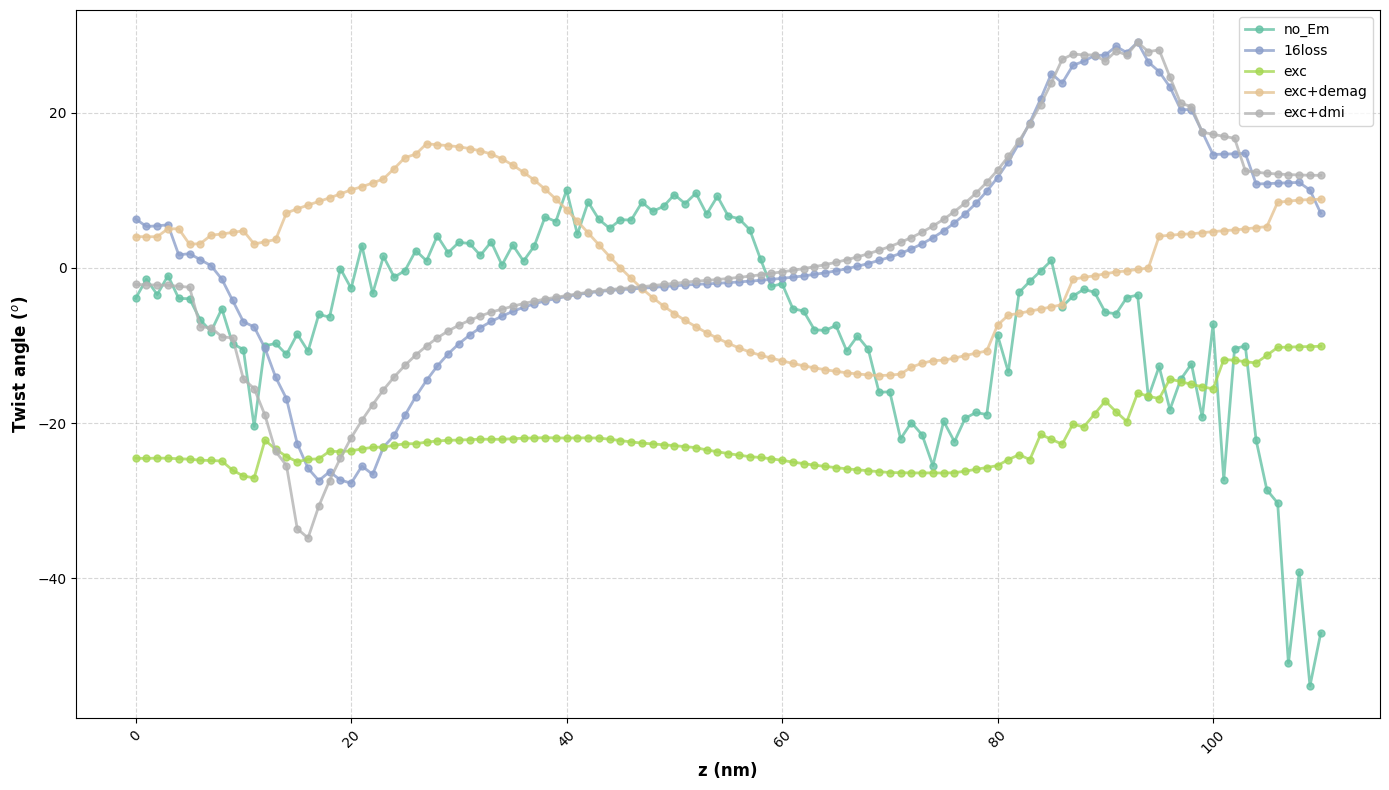

,label,valid_layer_count,mean_angle,std_angle
0,no_Em,111,-6.667498,12.476843
1,16loss,111,1.440391,14.042834
2,exc,111,-21.940508,4.437982
3,exc+demag,111,0.771939,9.169530
4,exc+dmi,111,1.397147,14.537840


In [7]:
plt.figure(figsize=(14, 8))
colors = plt.cm.Set2(np.linspace(0, 1, len(case_dirs)))
plot_stats = []

for case, color in zip(case_dirs, colors):
    label = case["label"]
    csv_path = TWIST_DIR / case["output_csv"]
    df = pd.read_csv(csv_path).sort_values("nz")
    valid_df = df[~df["angle"].isna()]

    if valid_df.empty:
        print(f"{label}: no valid data to plot")
        continue

    plt.plot(
        valid_df["nz"],
        valid_df["angle"],
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=5,
        color=color,
        alpha=0.8,
        label=label,
    )
    plot_stats.append({
        "label": label,
        "valid_layer_count": len(valid_df),
        "mean_angle": valid_df["angle"].mean(),
        "std_angle": valid_df["angle"].std(),
    })
    print(f"{label}: {len(valid_df)} valid layers, mean angle={valid_df['angle'].mean():.2f} degrees")

plt.xlabel("z (nm)", fontsize=12, fontweight="bold")
plt.ylabel("Twist angle ($^o$)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plot_stats_df = pd.DataFrame(plot_stats)
display(plot_stats_df)
